# 🔍 InFi-Check: Fine-tune Qwen2.5-7B với QLoRA (v3 — T4 Optimized)

**Pipeline:**
```
Upload JSONL → Load Qwen2.5-7B (4-bit) → QLoRA → Train → Eval → Lưu model
```

**Tối ưu v3 cho T4 16GB:**
- ✅ `r=16, alpha=32` — phù hợp T4, không OOM
- ✅ `lora_dropout=0.1` — regularization tốt
- ✅ `lr=5e-5, warmup=0.1` — hội tụ ổn định
- ✅ `clean_document()` — lọc HTML rác → token giảm ~40%
- ✅ `MAX_SEQ_LEN=1024` cứng — tránh OOM
- ✅ `1500 samples` — đủ học 6 loại lỗi, ~4-6h trên T4
- ✅ `save_steps=20` — checkpoint mỗi ~10 phút
- ✅ `DriveBackupCallback` — tự backup checkpoint lên Drive
- ✅ `do_sample=False` (greedy) — inference nhất quán
- ✅ `early_stopping patience=2` — dừng đúng lúc
- ✅ `apply_chat_template` — format đúng với Qwen2.5

**Yêu cầu:** GPU T4 16GB


## 1. Kiểm tra GPU

In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    # T4 không có bfloat16, A100/H100 có
    USE_BF16 = torch.cuda.is_bf16_supported()
    print(f'BF16 support   : {USE_BF16}  → sẽ dùng {"bf16" if USE_BF16 else "fp16"}')

Tue Apr 14 23:38:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Cài thư viện

In [2]:
!pip install -q \
    transformers==4.47.0 \
    trl==0.12.0 \
    peft==0.13.0 \
    bitsandbytes==0.44.1 \
    accelerate==1.1.1 \
    datasets==3.1.0 \
    huggingface_hub \
    sentencepiece \
    protobuf \
    scikit-learn
print('✅ Cài đặt hoàn tất!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires

## 3. Mount Drive & cấu hình đường dẫn

In [3]:
# ================================================================
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

import os, json

# ================================================================
# ✏️  CHỈNH nếu cần: đường dẫn file JSONL và thư mục lưu model
# ================================================================
SFT_ROOT  = '/content/drive/MyDrive/Phosphor-Bai-InFi-Check/training_dataset_construct/sft_dataset/jsonl'
SAVE_ROOT = '/content/drive/MyDrive/infi-check-qwen25-7b'

TRAIN_FILE = os.path.join(SFT_ROOT, 'summary_sft_train_pos1neg2_with_ref.jsonl')
VALID_FILE = os.path.join(SFT_ROOT, 'summary_sft_valid_with_ref.jsonl')
TEST_FILE  = os.path.join(SFT_ROOT, 'summary_sft_test_with_ref.jsonl')
# ================================================================

os.makedirs(SAVE_ROOT, exist_ok=True)

def count_jsonl(path):
    try:
        with open(path) as f:
            return sum(1 for _ in f)
    except:
        return 0

def count_labels(path):
    yes, no = 0, 0
    try:
        with open(path) as f:
            for line in f:
                text = json.loads(line)['text']
                answer = text.split('<|end_header_id|>:')[-1]
                if 'answer is YES' in answer: yes += 1
                else: no += 1
    except:
        pass
    return yes, no

for name, path in [('Train', TRAIN_FILE), ('Valid', VALID_FILE), ('Test', TEST_FILE)]:
    n = count_jsonl(path)
    yes, no = count_labels(path)
    ok = '✅' if n > 0 else '❌'
    print(f'{ok} {name}: {n} mẫu  |  YES: {yes}  |  NO: {no}')

print()
print('✅ Drive mounted thành công!')
print(f'   SFT_ROOT  : {SFT_ROOT}')
print(f'   SAVE_ROOT : {SAVE_ROOT}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Train: 5572 mẫu  |  YES: 3714  |  NO: 1858
✅ Valid: 200 mẫu  |  YES: 100  |  NO: 100
✅ Test: 200 mẫu  |  YES: 100  |  NO: 100

✅ Drive mounted thành công!
   SFT_ROOT  : /content/drive/MyDrive/Phosphor-Bai-InFi-Check/training_dataset_construct/sft_dataset/jsonl
   SAVE_ROOT : /content/drive/MyDrive/infi-check-qwen25-7b


## 4. Login HuggingFace

In [4]:
from huggingface_hub import login
login()

In [5]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

## 5. Load Qwen2.5-7B-Instruct (4-bit QLoRA)

In [6]:
import torch
!pip install -U triton bitsandbytes --quiet

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_ID = 'Qwen/Qwen2.5-7B-Instruct'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
    bnb_4bit_use_double_quant=True,
)

print('📥 Đang download Qwen2.5-7B-Instruct...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'right'

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
)
print(f'✅ Model loaded  |  VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')

📥 Đang download Qwen2.5-7B-Instruct...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

✅ Model loaded  |  VRAM: 5.6 GB


## 6. Cấu hình LoRA

In [7]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    # ✅ r=16: phù hợp T4 16GB, tránh OOM
    # r=32/64 tốt hơn về semantic nhưng OOM trên T4 với doc tiếng Việt dài
    r=16,
    lora_alpha=32,       # alpha = 2*r
    target_modules=[
        'q_proj', 'k_proj', 'v_proj', 'o_proj',   # Attention
        'gate_proj', 'up_proj', 'down_proj',        # MLP (FFN)
    ],
    lora_dropout=0.1,    # regularize tốt hơn dropout=0.05
    bias='none',
    task_type='CAUSAL_LM',
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'✅ LoRA configured  (r=16, alpha=32, dropout=0.1)')
print(f'   Trainable : {trainable:,} ({100*trainable/total:.2f}%)')
print(f'   Total     : {total:,}')
print(f'   VRAM      : {torch.cuda.memory_allocated()/1e9:.1f} GB')


✅ LoRA configured  (r=16, alpha=32, dropout=0.1)
   Trainable : 40,370,176 (0.92%)
   Total     : 4,393,342,464
   VRAM      : 8.0 GB


## 7. Load & format dataset

> **Key optimization**: Dùng `DataCollatorForCompletionOnlyLM` để chỉ tính loss
> trên phần **response** (sau `<|im_start|>assistant`), không tính loss trên
> instruction/document. Model học cách *phân tích lỗi*, không học lại document.

In [8]:
import re
import numpy as np
import shutil, os
from datasets import load_dataset, disable_caching

# ✅ Xóa cache để format_sample mới được áp dụng đúng
cache_dir = os.path.expanduser('~/.cache/huggingface/datasets')
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print('🗑️  Đã xóa HuggingFace dataset cache')
disable_caching()

SYSTEM_PROMPT = """Your task is to evaluate a summary by comparing it to the original document and identifying any errors present in the summary. These errors may involve incorrect information, over-simplifications, misrepresentations, or other discrepancies. Below are the possible types of errors you should consider:
- Semantic Frame Errors: Predicate Error, Entity Error, Circumstance Error
- Discourse Errors: Co-reference Error, Discourse Link Error
- Extrinsic Errors: Extrinsic Error (information introduced into the summary that is not present in or supported by the original document)

You are provided with the full text of the original document, and a summary of the document that might contain errors.

You should output:
1. Analyze the content of the summary compared to the original document. For each identified error, provide:
- Location: Where the error occurs in the summary.
- Explanation: Why the original meaning is altered or why the information is not supported by the document.
- Correction: A revised version of the erroneous part of the summary.
- Error Type: Specify the exact error type based on the categories listed above.
2. Answer whether the summary contains errors that make it not fully supported by the document."""


def clean_document(text: str) -> str:
    """Xóa HTML/UI rác từ các trang báo tiếng Việt."""
    cutoff_markers = [
        'Tặng sao', 'Chuyển sao', 'Tặng sao thành công',
        'Tuổi Trẻ Online', '© Copyright', 'Tin cùng chuyên mục',
        'Tuổi Trẻ Sao', 'Thông tin tài khoản', 'Đăng ký email',
        'Hotline:', 'Địa chỉ:', 'Tổng biên tập:',
        'Vui lòng nhập Email', 'Hiện chưa có bình luận',
    ]
    for marker in cutoff_markers:
        if marker in text:
            text = text[:text.index(marker)]
    text = re.sub(r'&[a-z]+_[^\s]+', '', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def format_sample(example):
    text  = example['text']
    parts = text.split('<|end_header_id|>:')
    instruction = parts[0].replace('<|start_header_id|>:', '').strip()
    response    = parts[1].strip() if len(parts) > 1 else ''

    if 'Document:' in instruction and 'Summary:' in instruction:
        doc_idx = instruction.index('Document:')
        sum_idx = instruction.index('Summary:')

        # ✅ Tách riêng doc và summary TRƯỚC khi clean
        doc_part = instruction[doc_idx:sum_idx].strip()
        sum_part = instruction[sum_idx:].strip()

        # ✅ Clean HTML rác rồi cắt cứng 600 ký tự cho document
        doc_part = clean_document(doc_part)[:300]

        # ✅ Cắt cứng 300 ký tự cho summary
        sum_part = sum_part[:150]

        user_msg = doc_part + '\n' + sum_part
    elif 'Document:' in instruction:
        user_msg = clean_document(instruction)[:600]
    else:
        user_msg = instruction

    messages = [
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': user_msg},
        {'role': 'assistant', 'content': response},
    ]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False,
    )
    return {'text': formatted}


# ✅ Load → select TRƯỚC → map sau (tránh cache toàn bộ 5572 samples)
raw = load_dataset('json', data_files={
    'train':      TRAIN_FILE,
    'validation': VALID_FILE,
})

# ✅ Shuffle và select 1000 samples TRƯỚC khi map
raw['train'] = raw['train'].shuffle(seed=42).select(range(1000))

# Map chỉ trên 1000 samples
dataset = raw.map(format_sample, num_proc=2)
MAX_SEQ_LEN = 384

# Kiểm tra token length
print('Đang tính phân phối độ dài token...')
lengths = []
for ex in dataset['train'].select(range(min(50, len(dataset['train'])))):
    toks = tokenizer(ex['text'], return_tensors='pt')
    lengths.append(toks['input_ids'].shape[1])

print(f'✅ Dataset loaded & formatted')
print(f'   Train : {len(dataset["train"])} mẫu')
print(f'   Valid : {len(dataset["validation"])} mẫu')
print(f'   Token — Min: {min(lengths)} | Mean: {int(np.mean(lengths))} | P95: {int(np.percentile(lengths,95))} | Max: {max(lengths)}')
print(f'   → MAX_SEQ_LEN: {MAX_SEQ_LEN}')

# ✅ Verify summary bị cắt đúng
sample_text = dataset['train'][0]['text']
if 'Summary:' in sample_text:
    si = sample_text.index('Summary:')
    print(f'\n   Summary (80 ký tự đầu): {sample_text[si:si+80]}')
print('\n   DataCollator: default (full sequence loss) ✅')
print('   HTML rác đã được lọc, doc+summary đã cắt cứng ✅')


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/200 [00:00<?, ? examples/s]

Đang tính phân phối độ dài token...
✅ Dataset loaded & formatted
   Train : 1000 mẫu
   Valid : 200 mẫu
   Token — Min: 549 | Mean: 699 | P95: 895 | Max: 1294
   → MAX_SEQ_LEN: 384

   Summary (80 ký tự đầu): Summary:
['Ngày 2/4, giá vàng trong nước giảm mạnh 3-4 triệu đồng/lượng.', 'Vàng

   DataCollator: default (full sequence loss) ✅
   HTML rác đã được lọc, doc+summary đã cắt cứng ✅


## 8. Training

In [9]:
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback, TrainerCallback
import shutil

OUTPUT_DIR = '/content/infi-check-qwen25-7b'
CKPT_DST   = '/content/drive/MyDrive/infi-check-qwen25-7b-ckpt'

# ✅ DriveBackupCallback — tự backup sau mỗi lần save, không cần cell riêng
class DriveBackupCallback(TrainerCallback):
    def __init__(self, src, dst):
        self.src = src
        self.dst = dst
        os.makedirs(dst, exist_ok=True)
    def on_save(self, args, state, control, **kwargs):
        ckpt = f'checkpoint-{state.global_step}'
        s, d = os.path.join(self.src, ckpt), os.path.join(self.dst, ckpt)
        if os.path.exists(s) and not os.path.exists(d):
            print(f'\n  📦 Backup {ckpt} → Drive...')
            shutil.copytree(s, d)
            print(f'  ✅ Done')
        return control

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,

    # --- Epoch ---
    num_train_epochs=2,

    # --- Batch ---
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,  # effective batch = 8

    # --- Optimizer ---
    optim='paged_adamw_8bit',
    learning_rate=5e-5,
    weight_decay=0.01,
    lr_scheduler_type='cosine',
    warmup_ratio=0.1,

    # --- Sequence ---
    max_seq_length=MAX_SEQ_LEN,
    dataset_text_field='text',

    # --- Eval & Save ---
    eval_strategy='steps',
    eval_steps=20,           # eval mỗi 50 steps (~25 phút)
    save_strategy='steps',
    save_steps=20,           # ✅ save mỗi 20 steps (~10 phút) — an toàn hơn
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,

    # --- Logging ---
    logging_steps=10,
    report_to='none',

    # --- Hardware ---
    bf16=USE_BF16,
    fp16=not USE_BF16,
    gradient_checkpointing=False,
    dataloader_pin_memory=False,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['validation'],
    tokenizer=tokenizer,
    # ✅ Không dùng data_collator — tránh lỗi 'Could not find response key'
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),  # ✅ patience=2
        DriveBackupCallback(OUTPUT_DIR, CKPT_DST),         # ✅ auto backup
    ],
)

steps_per_epoch = len(dataset['train']) // 8
est_h = steps_per_epoch * 3 * 30 / 3600
print(f'✅ Trainer sẵn sàng')
print(f'   Train : {len(dataset["train"])} | Valid: {len(dataset["validation"])}')
print(f'   LR: 5e-5 | Warmup: 10% | r=16 | MAX_SEQ: {MAX_SEQ_LEN}')
print(f'   Epochs: 3 | save mỗi 20 steps | eval mỗi 50 steps | patience=2')
print(f'   Ước tính: ~{est_h:.1f} giờ trên T4')


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

✅ Trainer sẵn sàng
   Train : 1000 | Valid: 200
   LR: 5e-5 | Warmup: 10% | r=16 | MAX_SEQ: 384
   Epochs: 3 | save mỗi 20 steps | eval mỗi 50 steps | patience=2
   Ước tính: ~3.1 giờ trên T4


In [10]:
lengths = []
for ex in dataset['train'].select(range(20)):
    toks = tokenizer(ex['text'], return_tensors='pt')
    lengths.append(toks['input_ids'].shape[1])
print(f'Min: {min(lengths)} | Mean: {sum(lengths)//len(lengths)} | Max: {max(lengths)}')

Min: 549 | Mean: 671 | Max: 925


In [11]:
import os, shutil

print('🚀 Bắt đầu fine-tuning...')

# ✅ Tự động resume từ checkpoint Drive nếu bị ngắt giữa chừng
last_ckpt = None
if os.path.exists(CKPT_DST):
    ckpts = sorted(
        [d for d in os.listdir(CKPT_DST) if d.startswith('checkpoint-')],
        key=lambda x: int(x.split('-')[1])
    )
    if ckpts:
        last_ckpt_name = ckpts[-1]
        src = os.path.join(CKPT_DST, last_ckpt_name)
        dst = os.path.join(OUTPUT_DIR, last_ckpt_name)
        if not os.path.exists(dst):
            print(f'  📦 Copy checkpoint từ Drive về /content...')
            shutil.copytree(src, dst)
        last_ckpt = dst
        print(f'  ▶️  Resume từ: {last_ckpt_name}')
    else:
        print('  🆕 Không có checkpoint — bắt đầu từ đầu')
else:
    print('  🆕 Không có checkpoint — bắt đầu từ đầu')

trainer.train(resume_from_checkpoint=last_ckpt)
print('\n✅ Training hoàn tất!')

🚀 Bắt đầu fine-tuning...
  📦 Copy checkpoint từ Drive về /content...
  ▶️  Resume từ: checkpoint-80


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
100,5.425300,0.340877
120,5.403100,0.339917



  📦 Backup checkpoint-100 → Drive...
  ✅ Done


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



  📦 Backup checkpoint-120 → Drive...
  ✅ Done


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



  📦 Backup checkpoint-124 → Drive...
  ✅ Done

✅ Training hoàn tất!


In [12]:
import shutil, os
src = '/content/infi-check-qwen25-7b'
dst = '/content/drive/MyDrive/infi-check-qwen25-7b-ckpt'
os.makedirs(dst, exist_ok=True)
for item in os.listdir(src):
    if item.startswith('checkpoint-'):
        s, d = os.path.join(src, item), os.path.join(dst, item)
        if not os.path.exists(d):
            shutil.copytree(s, d)
            print(f'✅ Backed up {item}')
        else:
            print(f'⏭️  Đã có {item}')
print('Done')

⏭️  Đã có checkpoint-124
⏭️  Đã có checkpoint-100
⏭️  Đã có checkpoint-120
Done


## 9. Lưu model lên Drive

In [13]:
trainer.model.save_pretrained(SAVE_ROOT)
tokenizer.save_pretrained(SAVE_ROOT)

with open(f'{SAVE_ROOT}/training_log.json', 'w') as f:
    json.dump(trainer.state.log_history, f, indent=2)

print(f'✅ Model lưu tại: {SAVE_ROOT}')
!du -sh {SAVE_ROOT}

✅ Model lưu tại: /content/drive/MyDrive/infi-check-qwen25-7b
170M	/content/drive/MyDrive/infi-check-qwen25-7b


## 10. Learning curve

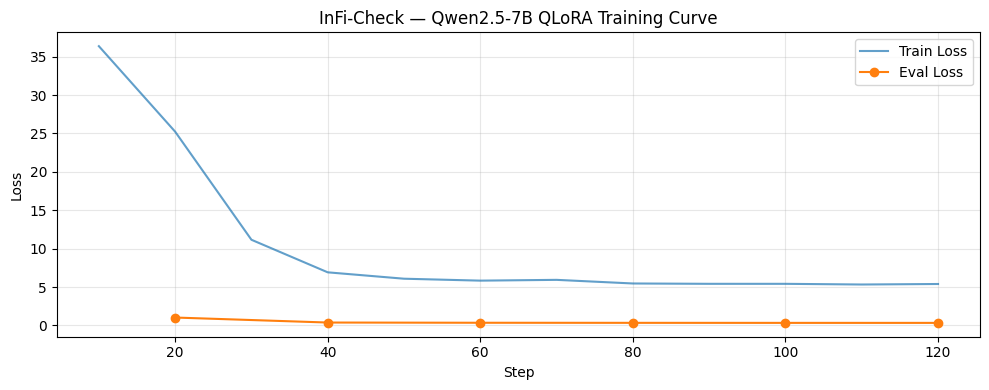

Best eval_loss: 0.3399 tại step 120


In [14]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_steps, train_loss = [], []
eval_steps, eval_loss   = [], []

for log in log_history:
    if 'loss' in log and 'eval_loss' not in log:
        train_steps.append(log['step']); train_loss.append(log['loss'])
    if 'eval_loss' in log:
        eval_steps.append(log['step']); eval_loss.append(log['eval_loss'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_steps, train_loss, label='Train Loss', alpha=0.7)
ax.plot(eval_steps,  eval_loss,  label='Eval Loss',  marker='o')
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('InFi-Check — Qwen2.5-7B QLoRA Training Curve')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_ROOT}/training_curve.png', dpi=150)
plt.show()

if eval_loss:
    best_step = eval_steps[eval_loss.index(min(eval_loss))]
    print(f'Best eval_loss: {min(eval_loss):.4f} tại step {best_step}')

## 11. Inference

In [15]:
model.eval()

def run_inference(document: str, summary: str, max_new_tokens: int = 512) -> str:
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': f'Document:\n{document}\nSummary:\n{summary}'},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors='pt').to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            # ✅ do_sample=False: greedy decode — ổn định, tái lập được
            # Fact-checking không cần sáng tạo, cần nhất quán
            do_sample=False,
            repetition_penalty=1.1,   # tránh lặp câu trong output dài
            pad_token_id=tokenizer.eos_token_id,
        )

    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)

print('✅ Inference function sẵn sàng')
print('   do_sample=False (greedy), repetition_penalty=1.1')


✅ Inference function sẵn sàng
   do_sample=False (greedy), repetition_penalty=1.1


In [16]:
# Test 1 mẫu từ test set
with open(TEST_FILE) as f:
    test_sample = json.loads(f.readline())

raw   = test_sample['text']
parts = raw.split('<|end_header_id|>:')
instr = parts[0].replace('<|start_header_id|>:', '').strip()
gt    = parts[1].strip()

doc_start = instr.index('Document:')
sum_start = instr.index('Summary:')
document  = instr[doc_start:sum_start].replace('Document:', '').strip()
summary   = instr[sum_start:].replace('Summary:', '').strip()

print('📄 DOCUMENT (300 ký tự):')
print(document[:300] + '...')
print('\n📝 SUMMARY:')
print(summary)
print('\n' + '='*60)
print('🎯 GROUND TRUTH:')
print(gt)
print('\n' + '='*60)
print('🤖 MODEL OUTPUT:')
print(run_inference(document, summary))

📄 DOCUMENT (300 ký tự):
TIÊU ĐỀ: Logistics Đông Nam Á xoay xở trong “bão giá” vận tải
THỜI GIAN: Mon, 30 Mar 2026 14:11:00 +07
NGUỒN: https://vtv.vn/logistics-dong-nam-a-xoay-xo-trong-bao-gia-van-tai-100260329211417373.htm
--------------------------------------------------

VTV.vn - Phí bảo hiểm, nhiên liệu tăng cao khiến ...

📝 SUMMARY:
['Xung đột Trung Đông tác động sâu sắc đến logistics toàn cầu và Đông Nam Á.', 'Tại Singapore, dòng chảy hàng hóa đang bắt đầu chậm lại.', 'Chúng nó bị ách hàng do giá nhiên liệu và cước vận chuyển tăng cao.', 'Chi phí logistics có thể tăng tới 50% do phí bảo hiểm rủi ro chiến tranh, giá nhiên liệu tăng cao, phụ phí khẩn cấp từ các công ty vận chuyển và chi phí đi đường vòng.', 'Doanh nghiệp buộc đàm phán lại chi phí với khách hàng và tìm phương án thay thế.', 'Các công ty Singapore đang theo dõi sát tình hình ở Trung Đông để có các quyết định như cắt giảm nhân sự và thu hẹp hoạt động nhằm giảm thiểu thiệt hại và rủi ro.']

🎯 GROUND TRUTH:
The followin

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


1. Analyze the content of the summary compared to the original document:

Location: Summary point about the impact of the conflict on logistics.
Explanation: The summary states that the conflict has affected logistics globally and in Southeast Asia without specifying the exact nature of the impact as described in the document. The document mentions specific issues such as delays due to higher fuel costs and shipping rates, increased insurance fees, and additional charges from carriers, which are not fully captured in the summary.
Correction: "Xung đột Trung Đông tác động sâu sắc đến chuỗi cung ứng và logistics toàn cầu, đặc biệt là tại khu vực Đông Nam Á."
Error Type: Semantic Frame Error - Predicate Error

Location: Summary point about the situation at Singapore.
Explanation: The summary simplifies the situation at Singapore by stating that the flow of goods is slowing down without providing context from the document that explains the reasons behind this slowdown.
Correction: "Tại Sin

## 12. Đánh giá toàn bộ test set

Ngoài Accuracy/F1 tổng, còn phân tích:
- Accuracy theo nhãn YES/NO riêng
- Phân phối error type bị nhận sai

Đánh giá 200 mẫu...


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


  10/200...
  20/200...
  30/200...
  40/200...
  50/200...
  60/200...
  70/200...
  80/200...
  90/200...
  100/200...
  110/200...
  120/200...
  130/200...
  140/200...
  150/200...
  160/200...
  170/200...
  180/200...
  190/200...
  200/200...

📊 KẾT QUẢ ĐÁNH GIÁ
              precision    recall  f1-score   support

   NO (đúng)       0.50      1.00      0.67       100
YES (có lỗi)       0.00      0.00      0.00       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


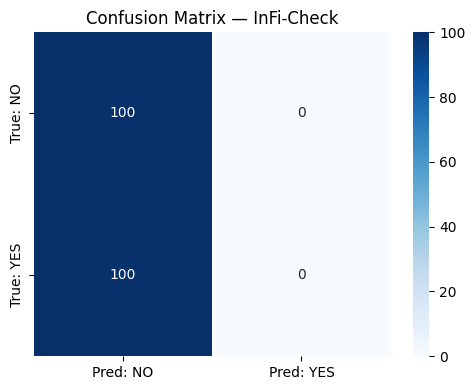


⚠️  False Negative theo error type (model bỏ sót lỗi):
   Co-reference Error             29
   Predicate Error                22
   Entity Error                   19
   Discourse Link Error           10
   Extrinsic Error                10
   Circumstance Error             10


In [17]:
import re
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []
# Lưu error type của ground truth để phân tích FP/FN theo loại lỗi
gt_error_types = []
inference_errors = []

with open(TEST_FILE) as f:
    test_samples = [json.loads(line) for line in f]

print(f'Đánh giá {len(test_samples)} mẫu...')

for i, sample in enumerate(test_samples):
    raw   = sample['text']
    parts = raw.split('<|end_header_id|>:')
    instr = parts[0].replace('<|start_header_id|>:', '').strip()
    gt    = parts[1].strip()

    doc_start = instr.index('Document:')
    sum_start = instr.index('Summary:')
    document  = instr[doc_start:sum_start].replace('Document:', '').strip()
    summary   = instr[sum_start:].replace('Summary:', '').strip()

    try:
        pred = run_inference(document, summary, max_new_tokens=256)
    except Exception as e:
        pred = ''
        inference_errors.append(i)

    true_label = 1 if 'answer is YES' in gt   else 0
    pred_label = 1 if 'answer is YES' in pred else 0

    y_true.append(true_label)
    y_pred.append(pred_label)

    # Lưu error type từ ground truth để phân tích
    et_match = re.search(r'- Error Type: (.+)', gt)
    gt_error_types.append(et_match.group(1).strip() if et_match else 'NO_ERROR')

    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(test_samples)}...')

# ── Kết quả tổng ────────────────────────────────────────────────────
print('\n' + '='*55)
print('📊 KẾT QUẢ ĐÁNH GIÁ')
print('='*55)
print(classification_report(y_true, y_pred, target_names=['NO (đúng)', 'YES (có lỗi)']))

# ── Confusion matrix ─────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: NO', 'Pred: YES'],
            yticklabels=['True: NO', 'True: YES'])
ax.set_title('Confusion Matrix — InFi-Check')
plt.tight_layout()
plt.savefig(f'{SAVE_ROOT}/confusion_matrix.png', dpi=150)
plt.show()

# ── Phân tích FN theo error type ─────────────────────────────────────
# False Negative: model nói NO nhưng thực tế có lỗi
fn_types = Counter()
for true, pred, et in zip(y_true, y_pred, gt_error_types):
    if true == 1 and pred == 0:  # FN
        fn_types[et] += 1

if fn_types:
    print('\n⚠️  False Negative theo error type (model bỏ sót lỗi):')
    for et, cnt in fn_types.most_common():
        print(f'   {et:<30} {cnt}')

if inference_errors:
    print(f'\n⚠️  {len(inference_errors)} mẫu lỗi inference: {inference_errors}')